# 15 — Calidad de curvas y mejora acotada por horizontes

**Pregunta:** ¿corregir pérdidas de información y adaptar el modelo al horizonte mejora H4–H5 sin deteriorar el conjunto?

Se parte de las proyecciones corregidas y de las bases oficiales. Se compara primero la misma arquitectura antes/después de calidad; luego se añade un bloque a la vez: separar H1–H2/H3–H5, memoria de doce semanas, historia de proyecciones y combinación sencilla. Las referencias de cuatro/ocho semanas y año anterior ya existían: no se presentan como novedades.

Los resultados de 2026 son desarrollo retrospectivo. La combinación fija sus pesos con predicciones temporales de noviembre–diciembre de 2025, antes de evaluar 2026. No se busca el mejor peso usando el resultado del ingeniero ni se promete ganar. Código autocontenido; ninguna celda ejecuta otro notebook ni importa módulos del proyecto.


In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from threadpoolctl import threadpool_limits

ROOT = next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"Datos_analiticos_proyecto").is_dir())
SALIDA = ROOT/"Datos_analiticos_proyecto"

KEY=['finca','producto','color','variedad']
DESTINO=SALIDA/'modelo_con_proyecciones_teoricas'
integrados=pd.read_parquet(DESTINO/'base_analitica_proyecciones.parquet')
datos=integrados.loc[integrados.y.notna()&integrados.admisible_modelo].copy()
categoricas=['producto','color','variedad']
temporales=['horizonte','semana_seno','semana_coseno']
memoria=['produccion_lag1','produccion_lag2','produccion_lag3','media_4','media_8','desv_4','tendencia_4_8','cambio_reciente','produccion_52']
climaticas=[v+s for v in ['temperatura_semana','humedad_semana','radiacion_semana'] for s in ['_lag1','_media4']]
agronomicas=[]
X_columnas=categoricas+temporales+memoria+climaticas
X_teoria=X_columnas+['teoria_modelo','antiguedad_curva','desviacion_reciente_teoria']
X_historia=X_teoria+['teoria_previa_1','teoria_previa_2','revision_teoria']
assert 'y' not in X_historia
assert not integrados.duplicated(KEY+['origen','horizonte']).any()

from IPython.display import display
AUD=ROOT/'Notebooks/Proyecciones Teoricas Propias/resultados_todos_los_anios/auditoria_calidad'


In [2]:
CORTES = [pd.Timestamp("2025-07-07"),pd.Timestamp("2026-01-05"),pd.Timestamp("2026-05-04")]
SEMANAS_EVALUACION = 8

def crear_modelo(nombre,columnas):
    numericas = [c for c in columnas if c not in categoricas]
    numerico = make_pipeline(SimpleImputer(strategy="median",add_indicator=True,keep_empty_features=True),
                             StandardScaler()) if nombre.startswith("Ridge") else SimpleImputer(
                                 strategy="median",add_indicator=True,keep_empty_features=True)
    preparar = ColumnTransformer([
        ("categorias",OneHotEncoder(handle_unknown="ignore",sparse_output=False,dtype=np.float32),categoricas),
        ("numericas",numerico,numericas)])
    estimador = Ridge(alpha=100.0) if nombre.startswith("Ridge") else HistGradientBoostingRegressor(
        learning_rate=.08,max_iter=80,max_leaf_nodes=15,min_samples_leaf=40,
        l2_regularization=1.0,early_stopping=False,random_state=42)
    return make_pipeline(preparar,estimador)
print("Sesgo positivo = el modelo quedó por debajo de lo reportado.")
print("±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.")


Sesgo positivo = el modelo quedó por debajo de lo reportado.
±8% procede del Plan de Proyecto; es referencia inicial, no aprobación operativa.


## 1. Diagnóstico: dónde se concentra la desventaja

La prioridad se define por exceso de error absoluto del modelo frente al ingeniero en tallos. Los porcentajes de contribución no representan participación en producción. Se desglosa por horizonte, producto, variedad, origen y ruta; las diferencias pueden ser negativas cuando el modelo mejora al experto. Los casos repetidos por horizonte no son inventario físico.


In [3]:
actual=pd.read_parquet(DESTINO/'comparacion_features_diarias_2026.parquet')
antes=pd.read_parquet(AUD/'modelo_antes_correccion.parquet')
llave=KEY+['origen','semana_objetivo','horizonte']
principal=actual.loc[actual.grupo_comparacion.eq('principal_estricta_nominal')].copy()
principal['error_modelo']=(principal.y-principal.Sistema_diario).abs()
principal['error_ingeniero']=(principal.y-principal.ingeniero).abs()
principal['exceso_error']=principal.error_modelo-principal.error_ingeniero
diagnosticos={}
for nombre,dims in [('Horizonte',['horizonte']),('Producto',['horizonte','producto']),('Variedad',['horizonte','producto','color','variedad']),('Semana',['horizonte','origen']),('Ruta',['horizonte','ruta_diaria'])]:
    t=principal.groupby(dims,dropna=False).agg(casos=('y','size'),real=('y','sum'),error_modelo=('error_modelo','sum'),error_ingeniero=('error_ingeniero','sum'),exceso_error=('exceso_error','sum')).reset_index()
    t['WAPE_modelo']=t.error_modelo/t.real; t['WAPE_ingeniero']=t.error_ingeniero/t.real
    diagnosticos[nombre]=t.sort_values('exceso_error',ascending=False)
    print(nombre);display(diagnosticos[nombre].head(12))


Horizonte


,horizonte,casos,real,error_modelo,error_ingeniero,exceso_error,WAPE_modelo,WAPE_ingeniero
4,5.0,2925,37987912,8751396.829049,8129858.0,621538.829049,0.230373,0.214012
3,4.0,3045,39433648,8765808.091009,8245782.0,520026.091009,0.222293,0.209105
2,3.0,3166,40558233,8252695.063172,8239427.0,13268.063172,0.203478,0.203151
0,1.0,3413,43114174,7251418.555131,7368295.0,-116876.444869,0.168191,0.170902
1,2.0,3289,42079208,7732567.128069,8114096.0,-381528.871931,0.183762,0.192829


Producto


,horizonte,producto,casos,real,error_modelo,error_ingeniero,exceso_error,WAPE_modelo,WAPE_ingeniero
55,5.0,CARNATION,1073,6920208,1937763.219545,1606616.0,331147.219545,0.280015,0.232163
42,4.0,CARNATION,1118,7170958,1936794.872394,1664380.0,272414.872394,0.270089,0.2321
44,4.0,MINICARNATION,881,24071863,4891880.584674,4620191.0,271689.584674,0.20322,0.191933
5,1.0,MINICARNATION,979,26014524,4041267.696275,3780827.0,260440.696275,0.155347,0.145335
57,5.0,MINICARNATION,848,23190692,4890084.44784,4639314.0,250770.44784,0.210864,0.200051
59,5.0,SOLOMIO,348,4214399,882269.8361,775997.0,106272.8361,0.209347,0.18413
46,4.0,SOLOMIO,360,4398965,891539.402481,819253.0,72286.402481,0.20267,0.186238
29,3.0,CARNATION,1165,7379424,1788788.025167,1726596.0,62192.025167,0.242402,0.233974
31,3.0,MINICARNATION,913,24719696,4592334.589213,4536688.0,55646.589213,0.185776,0.183525
33,3.0,SOLOMIO,372,4545645,866839.759548,823395.0,43444.759548,0.190697,0.181139


Variedad


,horizonte,producto,color,variedad,casos,real,error_modelo,error_ingeniero,exceso_error,WAPE_modelo,WAPE_ingeniero
556,5.0,MINICARNATION,HOT PINK,LORENZO,29,1582738,395042.237226,254570.0,140472.237226,0.249594,0.160842
437,4.0,MINICARNATION,HOT PINK,LORENZO,30,1647439,403948.516543,267065.0,136883.516543,0.245198,0.162109
328,3.0,MINICARNATION,PURPLE,EPSILON,31,1351514,281550.492461,155154.0,126396.492461,0.208322,0.1148
448,4.0,MINICARNATION,PURPLE,EPSILON,30,1322703,292494.079457,170041.0,122453.079457,0.221134,0.128556
567,5.0,MINICARNATION,PURPLE,EPSILON,29,1292577,294954.220023,198257.0,96697.220023,0.228191,0.153381
317,3.0,MINICARNATION,HOT PINK,LORENZO,31,1685723,369801.204845,273989.0,95812.204845,0.219372,0.162535
205,2.0,MINICARNATION,PURPLE,EPSILON,32,1389049,239729.756999,146971.0,92758.756999,0.172586,0.105807
82,1.0,MINICARNATION,PURPLE,EPSILON,33,1413035,222646.508745,142920.0,79726.508745,0.157566,0.101144
572,5.0,MINICARNATION,WHITE,WHISPER,29,771070,210097.566599,143216.0,66881.566599,0.272475,0.185737
516,5.0,CARNATION,LIGHT PINK,DONCEL,29,283300,116661.898333,53498.0,63163.898333,0.411796,0.188839


Semana


,horizonte,origen,casos,real,error_modelo,error_ingeniero,exceso_error,WAPE_modelo,WAPE_ingeniero
33,2.0,2026-01-12,112,1496906,516191.737383,287602.0,228589.737383,0.344839,0.192131
3,1.0,2026-02-02,109,1380698,504028.682295,327272.0,176756.682295,0.365054,0.237034
36,2.0,2026-02-02,107,1317169,456166.065315,314091.0,142075.065315,0.346323,0.238459
96,4.0,2026-01-12,109,1380698,467249.52394,326138.0,141111.52394,0.338415,0.236212
149,5.0,2026-06-29,99,1232367,296963.657482,162437.0,134526.657482,0.24097,0.131809
99,4.0,2026-02-02,107,1280036,402011.775038,270220.0,131791.775038,0.314063,0.211103
68,3.0,2026-02-02,108,1215237,368382.519921,238537.0,129845.519921,0.303136,0.196288
108,4.0,2026-04-06,99,1268237,357583.940893,229391.0,128192.940893,0.281954,0.180874
92,3.0,2026-07-27,101,1364596,344257.118892,224058.0,120199.118892,0.252278,0.164194
119,4.0,2026-06-29,99,1122410,262179.007123,144784.0,117395.007123,0.233586,0.128994


Ruta


,horizonte,ruta_diaria,casos,real,error_modelo,error_ingeniero,exceso_error,WAPE_modelo,WAPE_ingeniero
8,5.0,media4_con_diarios,2658,35332112,8128904.334436,7563128.0,565776.334436,0.230071,0.214058
6,4.0,media4_con_diarios,2778,36957942,8225789.343033,7706968.0,518821.343033,0.222572,0.208533
4,3.0,media4_con_diarios,2884,38112436,7768407.38701,7693740.0,74667.38701,0.203829,0.20187
9,5.0,teoria_con_diarios,267,2655800,622492.494613,566730.0,55762.494613,0.23439,0.213393
7,4.0,teoria_con_diarios,267,2475706,540018.747976,538814.0,1204.747976,0.218127,0.217641
1,1.0,teoria_con_diarios,325,2428629,454086.648473,453209.0,877.648473,0.186972,0.186611
3,2.0,teoria_con_diarios,301,2410055,468628.257211,525319.0,-56690.742789,0.194447,0.21797
5,3.0,teoria_con_diarios,282,2445797,484287.676162,545687.0,-61399.323838,0.198008,0.223112
0,1.0,media4_con_diarios,3088,40685545,6797331.906659,6915086.0,-117754.093341,0.16707,0.169964
2,2.0,media4_con_diarios,2988,39669153,7263938.870858,7588777.0,-324838.129142,0.183113,0.191302


## 2. Memoria adicional con calendario y prueba temporal

Se añaden media de doce semanas, dispersión de ocho/doce, tendencia entre cuatro y doce y conteos observados de cuatro/ocho/doce. Se requieren al menos cuatro reportes en la nueva media de doce; los conteos exponen su cobertura. No se imputan semanas sin producción como cero. El clima y las tendencias diarias se conservan sin nuevas transformaciones para aislar este cambio.


In [4]:
f=pd.read_parquet(SALIDA/'modelo_diario/features_diarias.parquet')
diarias=[c for c in f if c not in KEY+['fecha']]
integrados=integrados.merge(f.rename(columns={'fecha':'origen'}),on=KEY+['origen'],how='left',validate='many_to_one')
base=pd.read_parquet(DESTINO/'produccion_clima_semanal.parquet')
def memoria_larga(base):
    calendario=pd.DataFrame({'origen':pd.date_range(base.semana_inicio.min(),base.semana_inicio.max()+pd.Timedelta(weeks=1),freq='W-MON')})
    z=base[KEY].drop_duplicates().merge(calendario,how='cross').merge(base[KEY+['semana_inicio','tallos_reales']].rename(columns={'semana_inicio':'origen'}),on=KEY+['origen'],how='left',validate='one_to_one').sort_values(KEY+['origen'])
    g=z.groupby(KEY).tallos_reales
    z['media_12']=g.transform(lambda s:s.shift(1).rolling(12,min_periods=4).mean())
    for v in [8,12]:z[f'desv_{v}']=g.transform(lambda s:s.shift(1).rolling(v,min_periods=4).std())
    for v in [4,8,12]:z[f'reportes_{v}']=g.transform(lambda s:s.shift(1).rolling(v,min_periods=1).count())
    return z.drop(columns='tallos_reales')
extra=memoria_larga(base)
extra_cols=[c for c in extra if c not in KEY+['origen']]
integrados=integrados.merge(extra,on=KEY+['origen'],how='left',validate='many_to_one')
integrados['tendencia_4_12']=integrados.media_4-integrados.media_12
extra_cols+=['tendencia_4_12']
alterada=base.copy(); corte_prueba=pd.Timestamp('2025-01-06')
alterada.loc[alterada.semana_inicio.ge(corte_prueba),'tallos_reales']+=1000000
prueba=memoria_larga(alterada)
pd.testing.assert_frame_equal(extra.loc[extra.origen.le(corte_prueba)].reset_index(drop=True),prueba.loc[prueba.origen.le(corte_prueba)].reset_index(drop=True))
datos=integrados.loc[integrados.y.notna()&integrados.admisible_modelo].copy()
datos['grupo_h']=np.where(datos.horizonte.le(2),'H1_H2','H3_H5')
elegibles=datos.merge(actual[llave],on=llave,how='inner',validate='one_to_one')
assert len(elegibles)==len(actual)
Xbase=X_columnas+diarias
Xteoria=X_teoria+diarias
historia=['teoria_previa_1','teoria_previa_2','revision_teoria']
display(datos[extra_cols].isna().mean().mul(100).to_frame('faltantes_pct'))
print('Prueba temporal superada: alterar producción futura no cambia las variables disponibles al origen.')


,faltantes_pct
media_12,0.0
desv_8,0.0
desv_12,0.0
reportes_4,0.0
reportes_8,0.0
reportes_12,0.0
tendencia_4_12,0.0


Prueba temporal superada: alterar producción futura no cambia las variables disponibles al origen.


## 3. Experimentos fijados antes de ejecutar sus resultados

`Separado`: misma arquitectura y variables de 14, con modelos para H1–H2 y H3–H5. `Memoria_larga`: añade únicamente el bloque de la sección anterior. `Revisiones`: añade historia de proyecciones a las dos rutas, conservando faltantes. Todos usan los mismos parámetros y reglas de entrenamiento de 14. El respaldo sigue corrigiendo media4 y la ruta completa corrige teoría. Si no hay suficientes casos completos de entrenamiento, se utiliza el respaldo y se informa; no se ajusta un modelo con datos futuros.


In [5]:
def predecir(train,test,etapa):
    extras=[] if etapa=='Separado' else extra_cols
    revisiones=historia if etapa=='Revisiones' else []
    xb=Xbase+extras+revisiones; xt=Xteoria+extras+revisiones
    pred=pd.Series(index=test.index,dtype=float)
    for grupo,tt in test.groupby('grupo_h'):
        tr=train.loc[train.grupo_h.eq(grupo)]
        modelo=crear_modelo('Boosting',xb)
        with threadpool_limits(limits=2):
            modelo.fit(tr[xb],tr.y-tr.media_4)
            pred.loc[tt.index]=np.maximum(0,tt.media_4+modelo.predict(tt[xb]))
            tc=tr.loc[tr.curva_completa]; target=tt.loc[tt.curva_completa]
            if len(tc)>=40 and len(target):
                modelo_t=crear_modelo('Boosting',xt)
                modelo_t.fit(tc[xt],tc.y-tc.teoria_modelo)
                pred.loc[target.index]=np.maximum(0,target.teoria_modelo+modelo_t.predict(target[xt]))
            elif len(target):print('Respaldo por pocos casos completos:',grupo,len(tc))
    assert pred.notna().all() and pred.ge(0).all()
    return pred

# Selección pequeña de combinación ANTES de 2026, con objetivos cerrados antes del 1 de enero.
validacion=datos.loc[datos.origen.ge('2025-11-03') & (datos.semana_objetivo+pd.Timedelta(days=7)).le(pd.Timestamp('2026-01-01'))].copy()
validacion['pred_modelo']=np.nan
for mes,te in validacion.groupby(validacion.origen.dt.to_period('M')):
    corte=te.origen.min(); tr=datos.loc[(datos.semana_objetivo+pd.Timedelta(days=7)).le(corte)]
    validacion.loc[te.index,'pred_modelo']=predecir(tr,te,'Revisiones')
    print('Validación de pesos',mes,flush=True)
pesos=[]; candidatos=[]
for grupo,g in validacion.groupby('grupo_h'):
    for referencia in ['media_4','teoria_con_respaldo']:
        ref=g.media_4 if referencia=='media_4' else g.teoria_modelo.where(g.curva_completa,g.media_4)
        for peso in [0,.25,.5,.75,1]:
            pred=peso*g.pred_modelo+(1-peso)*ref
            candidatos.append({'grupo':grupo,'referencia':referencia,'peso_modelo':peso,'WAPE_validacion':(g.y-pred).abs().sum()/g.y.sum(),'casos':len(g)})
seleccion=pd.DataFrame(candidatos)
# En empate se prefiere más peso del modelo y media4, sin consultar 2026.
pesos=seleccion.sort_values(['WAPE_validacion','peso_modelo','referencia'],ascending=[True,False,True]).groupby('grupo',sort=False).head(1).set_index('grupo')
display(pesos)
resultados=[]; controles=[]
for mes,te in elegibles.groupby(elegibles.origen.dt.to_period('M')):
    corte=te.origen.min(); tr=datos.loc[(datos.semana_objetivo+pd.Timedelta(days=7)).le(corte)]
    assert tr.semana_objetivo.max()+pd.Timedelta(days=7)<=corte
    r=te[llave+['y','grupo_h','curva_completa','media_4','teoria_modelo']].copy()
    for etapa in ['Separado','Memoria_larga','Revisiones']:
        r[etapa]=predecir(tr,te,etapa)
        print(mes,etapa,'completo',flush=True)
    r['Combinacion']=np.nan
    for grupo,g in r.groupby('grupo_h'):
        p=pesos.loc[grupo]
        ref=g.media_4 if p.referencia=='media_4' else g.teoria_modelo.where(g.curva_completa,g.media_4)
        r.loc[g.index,'Combinacion']=p.peso_modelo*g.Revisiones+(1-p.peso_modelo)*ref
    r['corte_entrenamiento_nuevo']=corte
    resultados.append(r)
    controles.append({'mes':str(mes),'corte':corte,'train':len(tr),'test':len(te),'max_objetivo_train':tr.semana_objetivo.max()})
resultado=pd.concat(resultados,ignore_index=True)
resultado=actual.merge(resultado.drop(columns=['y','media_4','teoria_modelo']),on=llave,how='left',validate='one_to_one')
resultado=resultado.merge(antes[llave+['Sistema_diario']].rename(columns={'Sistema_diario':'Antes_calidad'}),on=llave,how='left',validate='one_to_one')
assert len(resultado)==len(actual)
assert resultado.corte_entrenamiento_nuevo.eq(resultado.corte_diario).all()
resultado.to_parquet(DESTINO/'experimentos_horizontes_2026.parquet',index=False)


Validación de pesos 2025-11


Validación de pesos 2025-12


,referencia,peso_modelo,WAPE_validacion,casos
grupo,,,,
H1_H2,media_4,1.0,0.169911,1790
H3_H5,media_4,1.0,0.267814,1758


2026-01 Separado completo


2026-01 Memoria_larga completo


...

2026-07 Memoria_larga completo


2026-07 Revisiones completo


2026-08 Separado completo


2026-08 Memoria_larga completo


2026-08 Revisiones completo


## 4. Comparación sobre los mismos casos y conclusión calculada

Se separa el cambio por calidad (`Antes_calidad` → `Sistema_diario`) del cambio por modelado. Se informa conjunto, horizonte, ruta, mes y segmentos. La combinación no se ajusta de nuevo al ver estos errores. Un candidato con menor error en este periodo es una mejora retrospectiva que requiere confirmación futura; ninguna prueba estadística convierte datos ya examinados en un test intacto.


Se añade una sensibilidad con cinco horizontes completos por serie/origen y remuestreo emparejado por semana objetivo. Los intervalos son exploratorios y no corrigen la selección tras examinar resultados.

,n,MAE,RMSE,WAPE,sesgo
metodo,,,,,
Memoria_larga,15838.0,2512.654861,4506.781338,0.195869,453.710858
Combinacion,15838.0,2520.495579,4564.447291,0.196481,507.820449
Revisiones,15838.0,2520.495579,4564.447291,0.196481,507.820449
Separado,15838.0,2524.209960,4552.792563,0.196770,469.212325
ingeniero,15838.0,2531.724839,4403.875315,0.197356,1250.135497
Antes_calidad,15838.0,2570.360189,4635.392756,0.200368,498.328171
Sistema_diario,15838.0,2573.171213,4643.430006,0.200587,501.637581


n          MAE         RMSE      WAPE  \
horizonte metodo                                                       
1.0       Antes_calidad   3413.0  2119.443716  3844.286210  0.167779   
          Combinacion     3413.0  1989.492638  3545.929612  0.157492   
          Memoria_larga   3413.0  1980.525381  3522.158918  0.156782   
          Revisiones      3413.0  1989.492638  3545.929612  0.157492   
          Separado        3413.0  1953.914815  3467.988317  0.154676   
          Sistema_diario  3413.0  2124.646515  3850.755469  0.168191   
          ingeniero       3413.0  2158.891005  3727.656625  0.170902   
2.0       Antes_calidad   3289.0  2348.735304  4294.277125  0.183582   
          Combinacion     3289.0  2238.113363  4027.845727  0.174936   
          Memoria_larga   3289.0  2246.210916  4020.925019  0.175569   
          Revisiones      3289.0  2238.113363  4027.845727  0.174936   
          Separado        3289.0  2229.929090  4028.186011  0.174296   
          Sistema_diario  3289.0  2351.038957  4302.120656  0.183762   
          ingeniero       3289.0  2467.040438  4271.206690  0.192829   
3.0       Antes_calidad   3166.0  2603.342939  4710.658123  0.203219   
          Combinacion     3166.0  2629.145606  4780.757212  0.205233   
          Memoria_larga   3166.0  2611.903890  4679.461369  0.203887   
          Revisiones      3166.0  2629.145606  4780.757212  0.205233   
          Separado        3166.0  2642.744059  4758.314285  0.206294   
          Sistema_diario  3166.0  2606.663002  4720.419317  0.203478   
          ingeniero       3166.0  2602.472205  4469.143353  0.203151   
4.0       Antes_calidad   3045.0  2877.960767  5119.879948  0.222231   
          Combinacion     3045.0  2876.198320  5152.514591  0.222095   
          Memoria_larga   3045.0  2866.826385  5075.071249  0.221372   
          Revisiones      3045.0  2876.198320  5152.514591  0.222095   
          Separado        3045.0  2907.556460  5176.825336  0.224517   
          Sistema_diario  3045.0  2878.754710  5125.886719  0.222293   
          ingeniero       3045.0  2707.974384  4686.461443  0.209105   
5.0       Antes_calidad   2925.0  2989.790963  5201.722282  0.230208   
          Combinacion     2925.0  2969.715171  5246.012540  0.228663   
          Memoria_larga   2925.0  2957.036856  5177.710024  0.227686   
          Revisiones      2925.0  2969.715171  5246.012540  0.228663   
          Separado        2925.0  2993.180238  5248.846729  0.230469   
          Sistema_diario  2925.0  2991.930540  5211.919674  0.230373   
          ingeniero       2925.0  2779.438632  4878.863188  0.214012   

                                sesgo  
horizonte metodo                       
1.0       Antes_calidad    368.774586  
          Combinacion      227.080651  
          Memoria_larga    216.367413  
          Revisiones       227.080651  
          Separado         299.354639  
          Sistema_diario   370.591706  
          ingeniero        955.342807  
2.0       Antes_calidad    520.346656  
          Combinacion      437.775551  
          Memoria_larga    436.499253  
          Revisiones       437.775551  
          Separado         486.206070  
          Sistema_diario   523.428178  
          ingeniero       1045.368805  
3.0       Antes_calidad    485.285893  
          Combinacion      605.995599  
          Memoria_larga    498.475162  
          Revisiones       605.995599  
          Separado         505.906307  
          Sistema_diario   489.678980  
          ingeniero       1211.956096  
4.0       Antes_calidad    602.298239  
          Combinacion      700.028748  
          Memoria_larga    599.288947  
          Revisiones       700.028748  
          Separado         586.164163  
          Sistema_diario   606.643375  
          ingeniero       1466.321182  
5.0       Antes_calidad    530.618966  
          Combinacion      607.801922  
          Memoria_larga    550.002511  
          Revisiones       607.801922  
      

n          MAE         RMSE  \
ruta_diaria        metodo                                              
media4_con_diarios Antes_calidad   14396.0  2652.429275  4760.301755   
                   Combinacion     14396.0  2599.577879  4678.632495   
                   Memoria_larga   14396.0  2592.260194  4620.931157   
                   Revisiones      14396.0  2599.577879  4678.632495   
                   Separado        14396.0  2601.519126  4664.044480   
                   Sistema_diario  14396.0  2652.429275  4760.301755   
                   ingeniero       14396.0  2602.646499  4522.236284   
teoria_con_diarios Antes_calidad    1442.0  1751.035248  3125.752875   
                   Combinacion      1442.0  1730.988780  3208.974227   
                   Memoria_larga    1442.0  1717.926446  3147.880568   
                   Revisiones       1442.0  1730.988780  3208.974227   
                   Separado         1442.0  1752.404998  3238.993417   
                   Sistema_diario   1442.0  1781.909726  3254.140169   
                   ingeniero        1442.0  1823.688627  2974.335142   

                                       WAPE        sesgo  
ruta_diaria        metodo                                 
media4_con_diarios Antes_calidad   0.200173   490.790648  
                   Combinacion     0.196184   500.940666  
                   Memoria_larga   0.195632   447.752254  
                   Revisiones      0.196184   500.940666  
                   Separado        0.196331   459.873227  
                   Sistema_diario  0.200173   490.790648  
                   ingeniero       0.196416  1281.400736  
teoria_con_diarios Antes_calidad   0.203366   573.577950  
                   Combinacion     0.201038   576.503777  
                   Memoria_larga   0.199521   513.197726  
                   Revisiones      0.201038   576.503777  
                   Separado        0.203525   562.447872  
                   Sistema_diario  0.206952   609.926378  
                   ingeniero       0.211804   938.003467

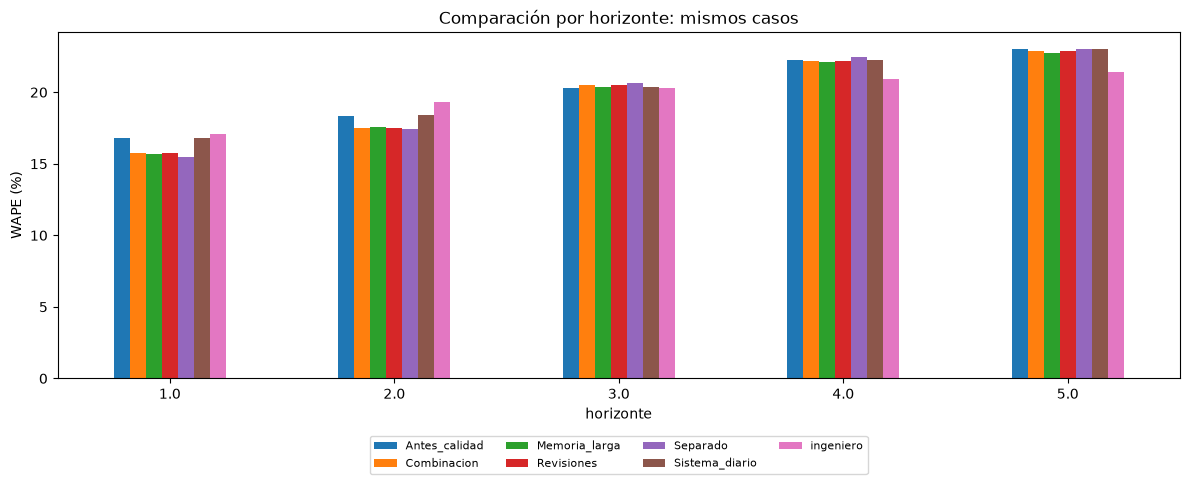

,n,MAE,RMSE,WAPE,sesgo
metodo,,,,,
Antes_calidad,14585.0,2653.558593,4754.136395,0.203107,532.132388
Combinacion,14585.0,2602.998514,4685.264531,0.199237,551.441009
Memoria_larga,14585.0,2596.651046,4625.189015,0.198751,492.178432
Revisiones,14585.0,2602.998514,4685.264531,0.199237,551.441009
Separado,14585.0,2609.817530,4673.507313,0.199759,505.048967
Sistema_diario,14585.0,2656.577993,4762.849502,0.203338,536.235197
ingeniero,14585.0,2616.041618,4523.993645,0.200236,1332.362770


,candidato,referencia,ventaja_pp,p025,p975
0,Sistema_diario,ingeniero,-0.323088,-1.739819,1.126610
1,Sistema_diario,Antes_calidad,-0.021913,-0.059079,0.015107
2,Separado,ingeniero,0.058581,-1.385019,1.447028
3,Separado,Antes_calidad,0.359756,0.148760,0.549216
4,Memoria_larga,ingeniero,0.148657,-1.159368,1.481832
5,Memoria_larga,Antes_calidad,0.449832,0.165902,0.666646
6,Revisiones,ingeniero,0.087536,-1.245611,1.427208
7,Revisiones,Antes_calidad,0.388711,0.147514,0.628217
8,Combinacion,ingeniero,0.087536,-1.330820,1.366649
9,Combinacion,Antes_calidad,0.388711,0.166126,0.616470


Intervalos exploratorios por semana objetivo; ventaja positiva favorece al candidato. No corrigen selección retrospectiva ni toda la dependencia temporal.


Menor error retrospectivo entre candidatos: Memoria_larga
WAPE candidato: 19.587 %; ingeniero: 19.736 %
Validación futura: fijar candidato, parámetros y pesos antes del próximo periodo no examinado, archivar fecha real de emisión y evaluar H1–H5 sobre casos comunes. No sustituir al experto por esta selección retrospectiva.


In [6]:
metodos=['ingeniero','Antes_calidad','Sistema_diario','Separado','Memoria_larga','Revisiones','Combinacion']
d=resultado.loc[resultado.grupo_comparacion.eq('principal_estricta_nominal')].copy()
assert d[metodos].notna().all().all()
larga=d.melt(id_vars=llave+['y','ruta_diaria','grupo_h'],value_vars=metodos,var_name='metodo',value_name='prediccion')
def metricas(g):
    e=g.y-g.prediccion
    return pd.Series({'n':len(g),'MAE':e.abs().mean(),'RMSE':np.sqrt((e**2).mean()),'WAPE':e.abs().sum()/g.y.sum(),'sesgo':e.mean()})
resumen=larga.groupby('metodo').apply(metricas)
horizonte=larga.groupby(['horizonte','metodo']).apply(metricas)
ruta=larga.groupby(['ruta_diaria','metodo']).apply(metricas)
producto=larga.groupby(['producto','metodo']).apply(metricas)
variedad=larga.groupby(['producto','color','variedad','metodo']).apply(metricas)
mes=larga.groupby([larga.origen.dt.to_period('M').astype(str),'metodo']).apply(metricas)
display(resumen.sort_values('WAPE'));display(horizonte);display(ruta)
ax=horizonte.WAPE.unstack().mul(100).plot.bar(figsize=(12,5),rot=0,ylabel='WAPE (%)',title='Comparación por horizonte: mismos casos')
ax.legend(loc='upper center',bbox_to_anchor=(.5,-.15),ncol=4,fontsize=8);plt.tight_layout();plt.show()
# Sensibilidad al exigir H1–H5 completos y remuestreo semanal emparejado.
panelkeys=KEY+['origen']
balance=d.loc[d.groupby(panelkeys).horizonte.transform('nunique').eq(5)]
balance_largo=balance.melt(id_vars=llave+['y'],value_vars=metodos,var_name='metodo',value_name='prediccion')
sensibilidad=balance_largo.groupby('metodo').apply(metricas)
rng=np.random.default_rng(42); intervalos=[]
for candidato in ['Sistema_diario','Separado','Memoria_larga','Revisiones','Combinacion']:
    for referencia in ['ingeniero','Antes_calidad']:
        z=pd.DataFrame({'semana':d.semana_objetivo,'real':d.y,'ventaja':(d.y-d[referencia]).abs()-(d.y-d[candidato]).abs()}).groupby('semana').sum()
        indices=rng.integers(0,len(z),size=(1000,len(z)))
        muestras=100*z.ventaja.to_numpy()[indices].sum(axis=1)/z.real.to_numpy()[indices].sum(axis=1)
        intervalos.append({'candidato':candidato,'referencia':referencia,'ventaja_pp':100*z.ventaja.sum()/z.real.sum(),'p025':np.quantile(muestras,.025),'p975':np.quantile(muestras,.975)})
incertidumbre=pd.DataFrame(intervalos)
display(sensibilidad);display(incertidumbre)
print('Intervalos exploratorios por semana objetivo; ventaja positiva favorece al candidato. No corrigen selección retrospectiva ni toda la dependencia temporal.')
with pd.ExcelWriter(DESTINO/'resultados_experimentos_horizontes.xlsx') as writer:
    for name,t in [('Resumen',resumen),('Horizonte',horizonte),('Ruta',ruta),('Producto',producto),('Variedad',variedad),('Mes',mes),('Pesos_pre2026',pesos),('Validacion_pesos',seleccion),('Cortes',pd.DataFrame(controles))]:t.to_excel(writer,sheet_name=name)
    for name,t in diagnosticos.items():t.to_excel(writer,sheet_name='Diagnostico_'+name,index=False)
    sensibilidad.to_excel(writer,sheet_name='Panel_H1_H5')
    incertidumbre.to_excel(writer,sheet_name='Incertidumbre',index=False)
ganador=resumen.drop(index=['ingeniero','Antes_calidad']).WAPE.idxmin()
print('Menor error retrospectivo entre candidatos:',ganador)
print('WAPE candidato:',round(100*resumen.loc[ganador,'WAPE'],3),'%; ingeniero:',round(100*resumen.loc['ingeniero','WAPE'],3),'%')
print('Validación futura: fijar candidato, parámetros y pesos antes del próximo periodo no examinado, archivar fecha real de emisión y evaluar H1–H5 sobre casos comunes. No sustituir al experto por esta selección retrospectiva.')


## 5. Lectura de resultados y siguiente decisión

**Qué ocurrió.** La corrección de calidad recupera historia y eleva la cobertura global de teoría completa a 21,25 % de los casos observados, pero la misma arquitectura queda en 20,06 % WAPE frente a 20,04 % antes. No debe atribuirse automáticamente una mejora de precisión a recuperar filas. En los casos principales de 2026 sólo 9.10 % utiliza la ruta teórica completa: el resto depende del respaldo, lo que explica por qué hay que estudiar ambas rutas.

**Qué experimento aporta.** Separar H1–H2/H3–H5 obtiene 19,68 %; añadir memoria larga baja a **19,59 %**, frente a **19,74 % del ingeniero**. La ventaja es aproximadamente 0,15 puntos y también aparece al exigir cinco horizontes completos (19,88 % frente a 20,02 %). H1/H2 mejoran; H3 queda cerca y H4/H5 siguen por detrás. El RMSE del ingeniero sigue siendo menor: 4.404 frente a 4.507 tallos. No afirmar superioridad en todos los horizontes ni en todas las métricas.

**Qué no aportó más.** Añadir revisiones obtiene 19,65 %, peor que memoria larga aunque mejor que la referencia inicial. La validación noviembre–diciembre de 2025 eligió peso 1 del modelo de revisiones en ambos grupos; por eso Combinacion y Revisiones coinciden. No hay beneficio demostrado de mezclarlos con media4/teoría en esta prueba, y no se cambian pesos para mejorar 2026.

**Dónde mirar.** En el diagnóstico de la arquitectura corregida, clavel y miniclavel concentran dificultades en horizontes largos. LORENZO y EPSILON aparecen entre los mayores excesos de error absoluto por variedad; la mayor desventaja de H4/H5 se encuentra en la ruta de respaldo. Estos hallazgos orientan revisión agronómica y de cobertura, no justifican ajustar a mano predicciones de las variedades evaluadas.

**Grado de evidencia.** El intervalo exploratorio de la ventaja de memoria larga frente al ingeniero es aproximadamente −1,16 a +1,48 puntos de WAPE; incluye cero. Frente al sistema previo a calidad, la mejora es 0,45 puntos, con intervalo +0,17 a +0,67. Ambos son remuestreos de datos ya examinados, no validación prospectiva. Memoria_larga queda como candidato para un periodo nuevo; no reemplaza automáticamente el insumo semanal fijado para el experimento diario.


## Continuación: diario, interpretación y train/test

Diario 04 aplica Memoria_larga al reparto conservando los pesos originales. El notebook 16 reconstruye agosto y grafica importancia por permutación. El 17 presenta el inventario, el error train/test del mismo corte y la evaluación acumulada por separado. Esta extensión no modifica las predicciones ni la selección retrospectiva de este notebook.